In [1]:
import numpy as np
import sys
import matplotlib.pyplot as plt

In [2]:
# Set parameters in the Hamiltonianin unit of f=GF/sqrt(2)/V
angle = 26.56/180.*np.pi #Sin(2*angle)=0.8
wbar = 0.0   #dm**2/(4*T*f)
tbar = 0.0   #T/f

In [3]:
prefix = 'pub/arXiv2404_16690/'

infile = prefix + 'Nn6'        # Input filename  
initj = 3   # n=6 nitial state

#infile = prefix + 'Nn8'      # Input filename  
#initj = 7   # n=8 nitial state

#infile = prefix + 'Nn10'      # Input filename  
#initj = 15   # n=8 nitial state

dt = 0.01               # Time step size
Nt = 300#1000              # Total time steps

In [4]:
# Set up momentum modes
P = []
with open(infile+'_p.dat', 'r') as f:
    for lines in f.readlines():
        l = [x for x in lines.split(' ')]
        if l[0] == '#':
            pass
        else:
            lf = [np.float64(x) for x in lines.split(' ')]
            P.append(lf)

P = np.array(P)
K = len(P)
Nb = 2 * K
print(f'Number of momentum modes: {K}')

Number of momentum modes: 35


In [5]:
# List states

states = []

with open(infile+'_s.dat', 'r') as f:
    for lines in f.readlines():
        l = [int(x) for x in lines.split(' ')]
        nstate = int(2**len(l)/4**(len(l)-len(list(set(l)))))
        rp = []
        if nstate < 2**len(l):
            for i in range(len(l)-1):
                if l[i]==l[i+1]:
                    rp.append(l[i])
        nrp = [x for x in l if x not in rp]
        numnrp = len(nrp)
        for i in range(nstate):
            state = []
            for j in range(len(rp)):
                state.append(2*rp[j])
                state.append(2*rp[j]+1)
            for j in range(numnrp):
                state.append(2*nrp[j]+(i//2**(numnrp-j-1))%2)
            states.append(sorted(state))

In [6]:
Nn = len(l)
bstr_to_j = {}
j_to_bstr = {}
Ns = len(states)
for i in range(Ns):
    b = ','.join(str(int(x)) for x in states[i])
    bstr_to_j[b] = i 
    j_to_bstr[i] = b


print(f'The number of basis states: {Ns}')
print(f'The number of neutrinos: {Nn}')

The number of basis states: 672
The number of neutrinos: 6


In [7]:
# Input is a state's binary representation, return its basis index j
def b_to_j(b):
    oc = []
    for i in range(Nb):
        if b[i]==1:
            oc.append(i)
    bstr = ','.join(str(x) for x in oc)
    return bstr_to_j[bstr]

# Input is the basis index j, and returns its binary representation
def j_to_b(j):
    bstr = j_to_bstr[j]
    oc = [int(x) for x in bstr.split(',')]
    b = [0]*Nb
    for i in range(len(oc)):
        b[oc[i]] = 1
    return b

In [8]:
# Given neutrino's mode index and flavor, return its bin number k = K*flavor + p
def bin(p, flavor):
    return 2*p + flavor

# given bin index (0 - Nb-1), returns momenta(index) and flavor
def pf(i):
    return i//2, i%2

In [9]:
# Applying a*(b1)a(b2) to a basis state, b = [b1,b2]
def quad(b, basis):
    basis_copy = basis.copy()
    l = 1
    f = 1.0
    if basis_copy[b[1]] == 0:
        l = 0
    else:
        basis_copy[b[1]] = 0
        f = f * (-1)**np.sum(basis_copy[:b[1]])
    if basis_copy[b[0]] ==1:
        l = 0
    else:
        basis_copy[b[0]] = 1
        f = f * (-1)**np.sum(basis_copy[:b[0]])
    return l, f, basis_copy

In [10]:
# Applying a*(b1)a*(b2)a(b3)a(b4) to state, b = [b1,b2,b3,b4]
def quar(b, basis):
    basis_copy = basis.copy()
    l = 1
    f = 1.0
    if basis_copy[b[3]] == 0:
        l = 0
    else:
        basis_copy[b[3]] = 0
        f = f * (-1)**np.sum(basis_copy[:b[3]])
    if basis_copy[b[2]] == 0:
        l = 0
    else:
        basis_copy[b[2]] = 0
        f = f * (-1)**np.sum(basis_copy[:b[2]])
    if basis_copy[b[1]] ==1:
        l = 0
    else:
        basis_copy[b[1]] = 1
        f = f * (-1)**np.sum(basis_copy[:b[1]])
    if basis_copy[b[0]] ==1:
        l = 0
    else:
        basis_copy[b[0]] = 1
        f = f * (-1)**np.sum(basis_copy[:b[0]])

    return l, f, basis_copy

In [11]:
# mass term applied to basis state j.
def mass(j):
    sin = j_to_b(j)
    state = np.zeros(Ns) * 1j
    for p in range(K):
        ke = bin(p, 0)
        km = bin(p, 1)
        absp = np.sqrt(np.sum(P[p]*P[p]))
        factor_ee = tbar*absp - np.cos(2*angle)*wbar/absp
        factor_mm = tbar*absp + np.cos(2*angle)*wbar/absp
        factor_em = np.sin(2*angle)*wbar/absp
        factor_me = factor_em
        t, fa, sout = quad([ke, ke], sin)
        # e -> e
        if t == 1:
            state[b_to_j(sout)] += fa * factor_ee 
        t, fa, sout = quad([km, km], sin) 
        # mu -> mu
        if t == 1:
            state[b_to_j(sout)] += fa * factor_mm 
        # mu -> e 
        t, fa, sout = quad([ke, km], sin) 
        if t == 1:
            state[b_to_j(sout)] += fa * factor_em 
        # e -> mu
        t, fa, sout = quad([km, ke], sin) 
        if t == 1:
            state[b_to_j(sout)] += fa * factor_me 

    return state

In [12]:
flavor_pair = np.array([[0,0],[0,1],[1,0],[1,1]]) # flavor (alpha, beta)

In [13]:
# Input is 3-dim momentum, returns |p|, theta and phi (0-2pi)
def p_spherical(p):
    absp = np.sqrt(np.sum(p*p))
    theta = np.arctan2(np.sqrt(p[0]**2+p[1]**2), p[2])
    phi = np.arctan2(p[1],p[0])
    return absp, theta, phi

# g factor for H_vv
def g_factor(p1, p2, q1, q2):
    absp1, tp1, pp1 = p_spherical(p1)
    absp2, tp2, pp2 = p_spherical(p2)
    absq1, tq1, pq1 = p_spherical(q1)
    absq2, tq2, pq2 = p_spherical(q2)
    fac1 = np.exp(-1j*pq1)*np.sin(tq1/2.)*np.cos(tq2/2.) - np.exp(-1j*pq2)*np.cos(tq1/2.)*np.sin(tq2/2.)
    fac2 = np.exp(1j*pp1)*np.sin(tp1/2.)*np.cos(tp2/2.) - np.exp(1j*pp2)*np.cos(tp1/2.)*np.sin(tp2/2.)
    return 2 * fac1 * fac2

# g factor for H_F
def g_factor_F(p1, p2, q1, q2):
    #if ((p1.all() == q1.all()) and (p2.all() == q2.all())):# or ((p1.all() == q2.all()) and (p2.all() == q1.all())):
    #    g_fac = g_factor(p1, p2, q1, q2)
    #else:
    #    g_fac = 0
    absp1, tp1, pp1 = p_spherical(p1)
    absp2, tp2, pp2 = p_spherical(p2)
    absq1, tq1, pq1 = p_spherical(q1)
    absq2, tq2, pq2 = p_spherical(q2)
    fac1 = np.exp(-1j*pq1)*np.sin(tq1/2.)*np.cos(tq2/2.) - np.exp(-1j*pq2)*np.cos(tq1/2.)*np.sin(tq2/2.)
    fac2 = np.exp(1j*pp1)*np.sin(tp1/2.)*np.cos(tp2/2.) - np.exp(1j*pp2)*np.cos(tp1/2.)*np.sin(tp2/2.)

    if (fac1 == np.conj(fac2)) or (fac1 == -np.conj(fac2)):
        g_fac = 2 * fac1 * fac2
    else:
        g_fac = 0
    
    return g_fac

In [14]:
print(f'Creating the list of conserved 4 momenta')
momenta4 = []
gfactors = []
for i1 in range(K):
    p1 = P[i1]
    for i2 in range(K):
        p2 = P[i2]
        for i3 in range(K):
            p3 = P[i3]
            for i4 in range(K):
                p4 = P[i4]
                pdiff = p1+p2-p3-p4
                if np.sum(np.abs(pdiff)) < 1e-7:
                    k1 = np.sqrt(np.sum(p1*p1))
                    k2 = np.sqrt(np.sum(p2*p2))
                    k3 = np.sqrt(np.sum(p3*p3))
                    k4 = np.sqrt(np.sum(p4*p4))
                    gfactor = g_factor(p1,p2,p3,p4)
                    if np.abs(k1+k2-k3-k4) < 1e-7 and np.abs(gfactor) > 1e-7:
                        momenta4.append([i1, i2, i3, i4])
                        gfactors.append(gfactor)


momenta4 = np.array(momenta4)
gfactors = np.array(gfactors)
print(f'Number of conserved P and conserved E pairs: {len(momenta4)}')  

# full 4 fermi interaction term applied to basis state j.
# a*(p1,fp1)a*(p2,fp2)a(q1,fq1)a(q2,fq2) with p1+p2 = q1+q2
def vv_full(j):
    sin = j_to_b(j)
    state = np.zeros(Ns) * 1j
    for i in range(len(momenta4)):
        p1 = momenta4[i,0]
        p2 = momenta4[i,1]
        q1 = momenta4[i,2]
        q2 = momenta4[i,3] 
        factor = - gfactors[i]
        for f in range(4):
            i1 = bin(p1, flavor_pair[f,0])
            i2 = bin(p2, flavor_pair[f,1])
            i3 = bin(q1, flavor_pair[f,0])
            i4 = bin(q2, flavor_pair[f,1])
            t, fa, sout = quar([i1, i2, i3, i4], sin)
            if t == 1:
                state[b_to_j(sout)] += fa * factor
    return state

Creating the list of conserved 4 momenta
Number of conserved P and conserved E pairs: 2564


In [15]:
print(f'Creating the list of conserved 4 momenta')
momenta4_F = []
gfactors_F = []
for i1 in range(K):
    p1 = P[i1]
    for i2 in range(K):
        p2 = P[i2]
        for i3 in range(K):
            p3 = P[i3]
            for i4 in range(K):
                p4 = P[i4]
                pdiff = p1+p2-p3-p4
                if np.sum(np.abs(pdiff)) < 1e-7:
                    k1 = np.sqrt(np.sum(p1*p1))
                    k2 = np.sqrt(np.sum(p2*p2))
                    k3 = np.sqrt(np.sum(p3*p3))
                    k4 = np.sqrt(np.sum(p4*p4))
                    gfactor_F = g_factor_F(p1,p2,p3,p4)
                    if np.abs(k1+k2-k3-k4) < 1e-7 and np.abs(gfactor_F) > 1e-7:
                        momenta4_F.append([i1, i2, i3, i4])
                        gfactors_F.append(gfactor_F)


momenta4_F = np.array(momenta4_F)
gfactors_F = np.array(gfactors_F)
print(f'Number of conserved P and conserved E pairs: {len(momenta4_F)}')  

# full 4 fermi interaction term applied to basis state j.
# a*(p1,fp1)a*(p2,fp2)a(q1,fq1)a(q2,fq2) with p1+p2 = q1+q2
def vv_F(j):
    sin = j_to_b(j)
    state = np.zeros(Ns) * 1j
    for i in range(len(momenta4_F)):
        p1 = momenta4_F[i,0]
        p2 = momenta4_F[i,1]
        q1 = momenta4_F[i,2]
        q2 = momenta4_F[i,3] 
        factor_F = - gfactors_F[i]
        for f in range(4):
            i1 = bin(p1, flavor_pair[f,0])
            i2 = bin(p2, flavor_pair[f,1])
            i3 = bin(q1, flavor_pair[f,0])
            i4 = bin(q2, flavor_pair[f,1])
            t, fa, sout = quar([i1, i2, i3, i4], sin)
            if t == 1:
                state[b_to_j(sout)] += fa * factor_F
    return state

Creating the list of conserved 4 momenta
Number of conserved P and conserved E pairs: 2116


In [16]:
H = np.zeros((Ns, Ns))*1j

for i in range(Ns):
    column = np.zeros(Ns)*1j
    H[:,i] += mass(i)
    H[:,i] += vv_full(i)
    if i%100==0:
        print(f'constructing {i}th column of the Hamiltonian')

# Diaginalize H and construct time evolution operator U
# Full Hamiltonian
hvals, hvecs = np.linalg.eigh(H) 
U = hvecs @ np.diag(np.exp(-dt*hvals*1j)) @ hvecs.conj().T

constructing 0th column of the Hamiltonian
constructing 100th column of the Hamiltonian
constructing 200th column of the Hamiltonian
constructing 300th column of the Hamiltonian
constructing 400th column of the Hamiltonian
constructing 500th column of the Hamiltonian
constructing 600th column of the Hamiltonian


In [17]:
H_F = np.zeros((Ns, Ns))*1j

for i in range(Ns):
    column = np.zeros(Ns)*1j
    H_F[:,i] += mass(i)
    H_F[:,i] += vv_F(i)
    if i%100==0:
        print(f'constructing {i}th column of the Hamiltonian')

# Diaginalize H and construct time evolution operator U
# Full Hamiltonian
hvals_F, hvecs_F = np.linalg.eigh(H_F) 
U_F = hvecs_F @ np.diag(np.exp(-dt*hvals_F*1j)) @ hvecs_F.conj().T

constructing 0th column of the Hamiltonian
constructing 100th column of the Hamiltonian
constructing 200th column of the Hamiltonian
constructing 300th column of the Hamiltonian
constructing 400th column of the Hamiltonian
constructing 500th column of the Hamiltonian
constructing 600th column of the Hamiltonian


In [18]:
# norm and observables of interest
def norm(state):
    return np.sqrt(np.sum(state * state.conj()))

# input is the state vector, returns the # of neutrino in each bin (Nb)
def observable(state):
    obs = np.zeros(Nb)
    for i in range(Ns):
        binary = j_to_b(i)
        obs += np.abs(state[i])**2*np.array(binary)
    return obs

# returns string of time and wave function amplitude
def print_cstr(state,i):
    return str(i*dt) + ' ' + ' '.join([str(x) for x in state]) 

# returns string of time and occupation number per bin
def print_nstr(state,i):
    obs = observable(state)
    return str(i*dt) + ' ' + ' '.join([str(x) for x in obs]) 


# Time evolution from the initial state j    
state = np.zeros(Ns)*1j
state[initj] = 1.0

In [19]:
Ns

672

In [20]:
init_state = state

In [21]:
[i for i, item in enumerate(j_to_b(initj)) if item != 0]

[0, 10, 20, 50, 57, 67]

In [22]:
[i for i, item in enumerate(init_state) if item != 0]

[3]

In [23]:
print(print_nstr(state,0))

for i in range(1,Nt+1):
    state = U @ state
    n = norm(state)
    if abs(n-1.) > 1e-5:
        print('Norm off by > 1e-5 at time ', i*dt)
        break
    print('-'*30)
    print(print_nstr(state,i))

0.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 1.0 0.0 0.0
------------------------------
0.01 0.9949411207325749 0.002586999487191404 0.0012339934373296155 0.001237929394422255 0.0 0.0 0.0008365831930271155 0.0008368637092967364 0.0 0.0 0.9968003637503992 0.0015261462957594418 0.0 0.0 0.0 0.0 0.0007471575212800518 5.733763599015454e-07 0.0 0.0 0.998333033107329 0.0009191929435133037 0.0 0.0 0.0 0.0 3.585252465614677e-08 7.19899320612078e-09 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 0.0 2.0210278934192806e-11 6.3934965803713515e-09 0.0 0.0 0.0 0.0 0.9992446007044542 7.668397906221324e-06 0.0 0.0 0.0007476216091443405 1.028747887533922e-07 0.0027141635477110604 0.9956123400847406 0.0 0.0 0.0008386500490607943 0.0008348399047809199 0.0 0.0 0.0012382

In [24]:
initj = 3

state = np.zeros(Ns)*1j
state[initj] = 1.0

init_state = state

times = []
times.append(0)

echo_6 = []
echo_6.append(np.abs(state @ init_state)**2)

#echo_8 = []
#echo_8.append(np.abs(state @ init_state)**2)

#echo_10 = []
#echo_10.append(np.abs(state @ init_state)**2)

for i in range(1, Nt+1):
    state = U @ state
    n = norm(state)
    if abs(n-1.) > 1e-5:
        print('Norm off by > 1e-5 at time ', i*dt)
        break
    print('-'*30)
    print(np.abs(state @ init_state)**2)
    times.append(i*dt)
    echo_6.append(np.abs(state @ init_state)**2)
    #echo_8.append(np.abs(state @ init_state)**2)
    #echo_10.append(np.abs(state @ init_state)**2)

------------------------------
0.9900982746056781
------------------------------
0.9610193857392931
------------------------------
0.9145792565623794
------------------------------
0.8536027927269345
------------------------------
0.7816487601832629
------------------------------
0.7026750041520333
------------------------------
0.6206851853376554
------------------------------
0.5393985675791182
------------------------------
0.4619789178529768
------------------------------
0.3908483775041268
------------------------------
0.32759904025692393
------------------------------
0.2730011035061554
------------------------------
0.22709400190190046
------------------------------
0.18933766223588425
------------------------------
0.1587960559805964
------------------------------
0.13432489352418756
------------------------------
0.11473913882647033
------------------------------
0.09894292479802576
------------------------------
0.08601293212993236
------------------------------
0.0752347829

In [25]:
initj = 3

state = np.zeros(Ns)*1j
state[initj] = 1.0

init_state = state

times = []
times.append(0)

echo_6_F = []
echo_6_F.append(np.abs(state @ init_state)**2)

for i in range(1, Nt+1):
    state = U_F @ state
    n = norm(state)
    if abs(n-1.) > 1e-5:
        print('Norm off by > 1e-5 at time ', i*dt)
        break
    print('-'*30)
    print(np.abs(state @ init_state)**2)
    times.append(i*dt)
    echo_6_F.append(np.abs(state @ init_state)**2)
    #echo_8.append(np.abs(state @ init_state)**2)
    #echo_10.append(np.abs(state @ init_state)**2)

------------------------------
0.9972801682124929
------------------------------
0.9891586192326306
------------------------------
0.9757485375925997
------------------------------
0.9572363941582436
------------------------------
0.9338787329826806
------------------------------
0.9059977558660854
------------------------------
0.8739757857213697
------------------------------
0.8382487103919188
------------------------------
0.7992985272134523
------------------------------
0.7576451250091447
------------------------------
0.7138374540494589
------------------------------
0.6684442455376824
------------------------------
0.6220444501938576
------------------------------
0.5752175703552093
------------------------------
0.5285340616014355
------------------------------
0.4825459782205235
------------------------------
0.4377780318890142
------------------------------
0.39471922484476774
------------------------------
0.353815207734369
------------------------------
0.3154614984318233


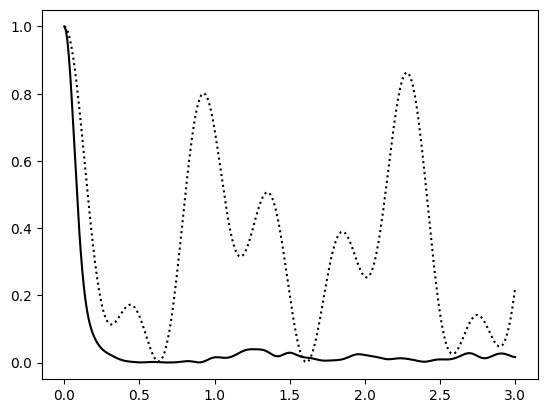

In [26]:
plt.plot(times, echo_6, color = 'black')
plt.plot(times, echo_6_F, color = 'black', linestyle = 'dotted')
#plt.plot(times, echo_8, color = 'blue')

#plt.savefig('fig7_n6.pdf')
#plt.plot(times, echo_8, color = 'blue')
#plt.plot(times, echo_10, color = 'red')

NameError: name 'echo_8' is not defined

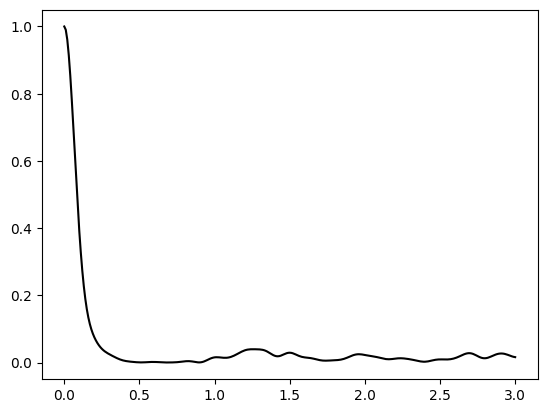

In [27]:
plt.plot(times, echo_6, color = 'black')
plt.plot(times, echo_8, color = 'blue')

#plt.savefig('fig7_n6_n8.pdf')
#plt.plot(times, echo_10, color = 'red')

In [ ]:
H_F.all() == H.all()

In [ ]:
U_F.diagonal()

In [ ]:
sum(U.diagonal())